## Analisis Transaksi Pengalihan Hak atas Tanah dan/atau Bangunan (PHTB) dan PPh Final Menggunakan Data Analytics dan Machine Learning dengan Metode Regresi dan Clustering

In [1]:
# Import Library yang dibutuhkan

#Importing the Libraries
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt, numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")
np.random.seed(42)

In [2]:
# Baca file parquet untuk Data Analysis

file_parquet_laptop = "C:/Users/user/OneDrive - Kemenkeu/Karejo/PJJ/10. Data Analytics/intro-python/MLFlow/4. PPHTB  999 - 15 10 2024.parquet"
# file_parquet = "C:/Users/910223073/OneDrive - Kemenkeu/Karejo/PJJ/10. Data Analytics/intro-python/MLFlow/4. PPHTB  999 - 15 10 2024.parquet"
df_parquet = pd.read_parquet(file_parquet_laptop)
df_parquet.head()

,nama_wp,tempat_lapor,KPPADM_NOTARIS,KPPADM_PEMBELI,KPPADM_PENJUAL,NOMOR_SURAT,TGL_SURAT,CREATION_DATE,NPWP_NOTARIS,NAMA_NOTARIS,...,HARGA,JML_PPHFINAL_TERUTANG,NTPN,TGL_BAYAR,JUMLAH_BAYAR,e_pphtbnotaris,TAHUN_SURAT,TAHUN_TRANSAKSI,TAHUN_BAYAR,JENIS_OBJEK_PAJAK
0,CHOESNOEL AISYAH,NaN,626.0,nan,626.0,SKET-4707/PHTB/KPP.120703/2022,2022-10-11,11-OCT-22 09.34.12.891000 AM,640942785626000,ERNA TRI MOERHADIATI,...,600000000,15000000.0,3AC663IED1J3LJ6C,2022-10-04,15000000.0,Y,2022,2022,2022,Tanah dan Bangunan
1,IR.A.TOSSIN SUHARYA,NaN,416.0,29.0,73.0,SKET-6308/PHTB/KPP.081203/2023,2023-12-18,18-DEC-23 03.45.56.065000 PM,243267531416000,MOHAMAD ABROR,...,21000000,525000.0,2D1345BANL29RJ2K,2023-12-15,525000.0,Y,2023,2023,2023,Tanah Kosong
2,IR.A.TOSSIN SUHARYA,NaN,416.0,29.0,73.0,SKET-6278/PHTB/KPP.081203/2023,2023-12-18,18-DEC-23 03.06.29.978000 PM,243267531416000,MOHAMAD ABROR,...,252840000,6321000.0,0D2A44ET7QA2K9DA,2023-12-15,6321000.0,Y,2023,2023,2023,Tanah Kosong
3,IR.A.TOSSIN SUHARYA,NaN,416.0,29.0,73.0,SKET-6307/PHTB/KPP.081203/2023,2023-12-18,18-DEC-23 03.42.17.892000 PM,243267531416000,MOHAMAD ABROR,...,321000000,8025000.0,61C174ET7QFSQGFC,2023-12-15,8025000.0,Y,2023,2023,2023,Tanah Kosong
4,IR.A.TOSSIN SUHARYA,NaN,416.0,29.0,73.0,SKET-6226/PHTB/KPP.081203/2023,2023-12-15,15-DEC-23 03.33.00.106000 PM,243267531416000,MOHAMAD ABROR,...,180000000,4500000.0,CB7872M285D2C1SR,2023-12-15,4500000.0,Y,2023,2023,2023,Tanah Kosong


## CRISP-DM Phase 1: Business Understanding

### Latar Belakang
Direktorat Jenderal Pajak (DJP) mengelola data transaksi Pengalihan Hak atas Tanah dan/atau Bangunan (PHTB) yang dilaporkan melalui validasi PPh Final Pasal 4(2). Salah satu tantangan utama adalah mendeteksi potensi **under-reporting harga transaksi** oleh Wajib Pajak.

### Tujuan
Membangun model Machine Learning untuk **memprediksi harga transaksi properti (HARGA)** berdasarkan karakteristik objek dan transaksi. Model ini dapat digunakan untuk:
1. **Deteksi anomali harga** — mengidentifikasi transaksi dengan harga yang jauh di bawah prediksi model
2. **Analisis kewajaran harga** — sebagai benchmark harga wajar berdasarkan luas tanah, bangunan, jenis objek, dll
3. **Profiling risiko** — mendukung pengawasan dan pemeriksaan pajak

### Target & Features
| Variabel | Peran | Deskripsi |
|---|---|---|
| **HARGA** | Target (y) | Harga transaksi pengalihan properti |
| LUAS_TANAH | Feature | Luas tanah (m²) |
| LUAS_BANGUNAN | Feature | Luas bangunan (m²) |
| TARIF_PPH | Feature | Tarif PPh Final yang diterapkan (%) |
| JENIS_PENGALIHAN | Feature | Jenis pengalihan (lainnya, rss, kik, PPJB, dll) |
| JENIS_OBJEK_PAJAK | Feature | Jenis objek (Tanah dan Bangunan, Tanah Kosong, Apartemen, dll) |
| JNS_PENJUAL | Feature | Jenis penjual (OP, BADAN, BENDAHARA) |
| TAHUN_TRANSAKSI | Feature | Tahun transaksi (2020-2024) |

### Model yang Digunakan
1. **Linear Regression** — sebagai baseline model
2. **Random Forest Regressor** — untuk menangkap non-linearitas

### Strategi Sampling
Mengingat keterbatasan hardware (Intel Core i5-4300, 8GB DDR3, SSD SATA), dari ~8 juta baris data (2020-2024) akan diambil **300.000 sampel** secara stratified berdasarkan TAHUN_TRANSAKSI agar proporsional.

## CRISP-DM Phase 2: Data Understanding

In [3]:
# 2.1 Gambaran Umum Dataset
print(f"Jumlah baris total : {df_parquet.shape[0]:,}")
print(f"Jumlah kolom total : {df_parquet.shape[1]}")
print(f"\nDistribusi Tahun Transaksi:")
print(df_parquet['TAHUN_TRANSAKSI'].value_counts().sort_index())

# Bebaskan memory dari dataframe besar (48 kolom)
import gc
del df_parquet
gc.collect()
print("\n[INFO] Memory dari df_parquet (48 kolom) telah dibebaskan.")

Jumlah baris total : 8,966,277
Jumlah kolom total : 48

Distribusi Tahun Transaksi:
TAHUN_TRANSAKSI
2002         13
2003         16
2004         18
2005         25
2006         28
2007         24
2008         30
2009         18
2010         34
2011         29
2012         35
2013         85
2014         84
2015        111
2016        835
2017       1602
2018     156903
2019     780391
2020    1236568
2021    1456417
2022    1807304
2023    2048853
2024    1476854
Name: count, dtype: Int64

[INFO] Memory dari df_parquet (48 kolom) telah dibebaskan.


In [4]:
# 2.2 Baca ulang parquet hanya kolom yang dibutuhkan + filter 2020-2024
import pyarrow.parquet as pq

kolom_model = ['LUAS_TANAH', 'LUAS_BANGUNAN', 'TARIF_PPH', 'HARGA', 
               'JML_PPHFINAL_TERUTANG', 'JUMLAH_BAYAR', 'TAHUN_TRANSAKSI',
               'JENIS_PENGALIHAN', 'JENIS_OBJEK_PAJAK', 'JNS_PENJUAL']

# Baca hanya kolom yang dibutuhkan (hemat RAM)
df = pd.read_parquet(file_parquet_laptop, columns=kolom_model)
df = df[df['TAHUN_TRANSAKSI'].between(2020, 2024)].reset_index(drop=True)

print(f"Jumlah baris (2020-2024): {len(df):,}")
print(f"Jumlah kolom            : {len(df.columns)}")
print(f"Memory usage            : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Statistik Deskriptif
kolom_numerik = ['LUAS_TANAH', 'LUAS_BANGUNAN', 'HARGA', 'JML_PPHFINAL_TERUTANG', 'JUMLAH_BAYAR', 'TARIF_PPH']
df[kolom_numerik].describe().round(2)

Jumlah baris (2020-2024): 8,025,996
Jumlah kolom            : 10
Memory usage            : 841.4 MB


,LUAS_TANAH,LUAS_BANGUNAN,HARGA,JML_PPHFINAL_TERUTANG,JUMLAH_BAYAR,TARIF_PPH
count,8.025996e+06,8.025996e+06,8.025996e+06,8.025996e+06,8.025996e+06,8025996.00
mean,2.650810e+03,5.381590e+03,6.166024e+08,1.781065e+07,6.482622e+06,2.74
std,9.008333e+05,1.871589e+06,3.953942e+09,1.110932e+08,7.816493e+07,1.10
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.50
25%,6.000000e+01,1.784000e+01,1.030400e+08,1.749500e+06,5.000000e+05,2.50
50%,8.400000e+01,3.600000e+01,2.000000e+08,5.705700e+06,1.505000e+06,2.50
75%,1.510000e+02,7.700000e+01,5.500000e+08,1.647727e+07,3.912500e+06,2.50
max,1.180350e+09,9.100000e+08,3.500000e+12,8.750000e+10,8.750000e+10,5.00


In [5]:
# 2.3 Distribusi Kolom Kategorikal
print("JENIS_OBJEK_PAJAK:")
print(df['JENIS_OBJEK_PAJAK'].value_counts())
print("\nJENIS_PENGALIHAN:")
print(df['JENIS_PENGALIHAN'].value_counts())
print("\nJNS_PENJUAL:")
print(df['JNS_PENJUAL'].value_counts())
print("\nTARIF_PPH:")
print(df['TARIF_PPH'].value_counts().sort_index())

JENIS_OBJEK_PAJAK:
JENIS_OBJEK_PAJAK
Tanah dan Bangunan       5494793
Tanah Kosong             1824942
Apartemen/Rumah Susun     700413
Data Tidak Valid            5848
Name: count, dtype: int64

JENIS_PENGALIHAN:
JENIS_PENGALIHAN
4          6131080
lainnya     934861
3           813338
PPJB         73043
rss          66569
KIK           1235
kik             14
Name: count, dtype: int64

JNS_PENJUAL:
JNS_PENJUAL
1BADAN       5017768
0OP          2000168
OP            793359
BADAN         207894
2               6616
BENDAHARA        191
Name: count, dtype: int64

TARIF_PPH:
TARIF_PPH
0.500000        752
1.000000     888658
2.500000    5835288
2.700000          7
2.977155         16
3.026395          2
3.118643         19
3.750000          1
4.390000         12
5.000000    1301241
Name: count, dtype: int64


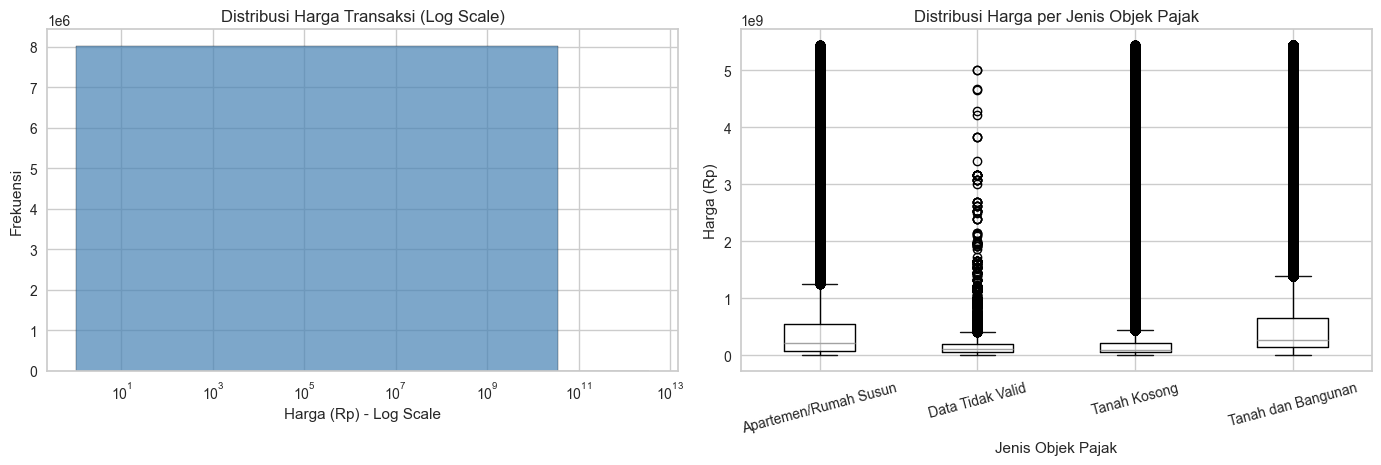

In [6]:
# 2.4 Visualisasi Distribusi Harga Transaksi (Log Scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi HARGA (log scale)
axes[0].hist(df['HARGA'][df['HARGA'] > 0], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xscale('log')
axes[0].set_title('Distribusi Harga Transaksi (Log Scale)', fontsize=12)
axes[0].set_xlabel('Harga (Rp) - Log Scale')
axes[0].set_ylabel('Frekuensi')

# Boxplot HARGA per Jenis Objek
df_box = df[df['HARGA'].between(1, df['HARGA'].quantile(0.99))]
df_box.boxplot(column='HARGA', by='JENIS_OBJEK_PAJAK', ax=axes[1], vert=True)
axes[1].set_title('Distribusi Harga per Jenis Objek Pajak', fontsize=12)
axes[1].set_xlabel('Jenis Objek Pajak')
axes[1].set_ylabel('Harga (Rp)')
axes[1].tick_params(axis='x', rotation=15)
plt.suptitle('')

plt.tight_layout()
plt.show()

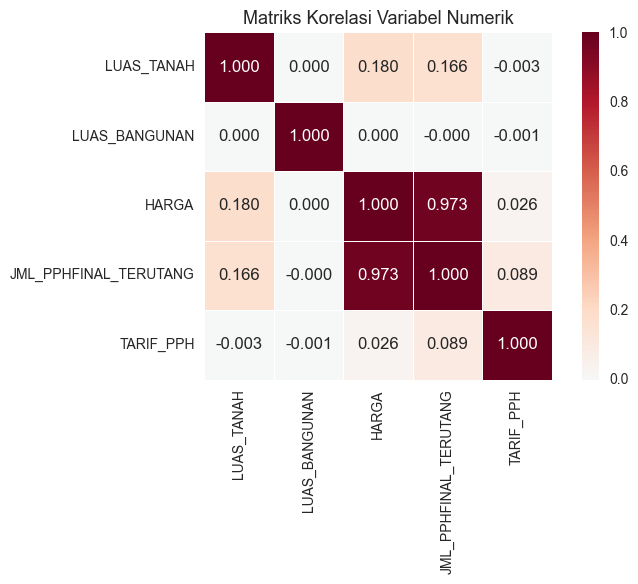

In [7]:
# 2.5 Korelasi antar Variabel Numerik
kolom_korelasi = ['LUAS_TANAH', 'LUAS_BANGUNAN', 'HARGA', 'JML_PPHFINAL_TERUTANG', 'TARIF_PPH']
# Sampling untuk hitung korelasi (hemat memory)
corr_sample = df[kolom_korelasi].sample(n=100000, random_state=42)
corr_matrix = corr_sample.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5)
plt.title('Matriks Korelasi Variabel Numerik', fontsize=13)
plt.tight_layout()
plt.show()

## CRISP-DM Phase 3: Data Preparation

Langkah-langkah:
1. Seleksi kolom yang relevan (target + features)
2. Pembersihan data: hapus missing values, data tidak valid, dan outlier ekstrem
3. Standardisasi kategori (mapping value yang inkonsisten)
4. Encoding variabel kategorikal
5. Stratified sampling 300.000 baris
6. Train-test split (80:20)

In [8]:
# 3.1 Seleksi Kolom & Pembersihan Data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Kolom yang digunakan
features_cat = ['JENIS_PENGALIHAN', 'JENIS_OBJEK_PAJAK', 'JNS_PENJUAL']
features_num = ['LUAS_TANAH', 'LUAS_BANGUNAN', 'TARIF_PPH', 'TAHUN_TRANSAKSI']
target = 'HARGA'

kolom_pakai = features_cat + features_num + [target]
df_model = df[kolom_pakai].copy()

print(f"Jumlah baris awal: {len(df_model):,}")

# Hapus missing values
df_model = df_model.dropna()
print(f"Setelah hapus missing: {len(df_model):,}")

# Hapus data tidak valid
df_model = df_model[df_model['JENIS_OBJEK_PAJAK'] != 'Data Tidak Valid']
print(f"Setelah hapus 'Data Tidak Valid': {len(df_model):,}")

# Hapus HARGA <= 0 dan LUAS_TANAH <= 0
df_model = df_model[(df_model['HARGA'] > 0) & (df_model['LUAS_TANAH'] > 0)]
print(f"Setelah hapus HARGA/LUAS_TANAH <= 0: {len(df_model):,}")

# Hapus outlier ekstrem menggunakan IQR pada HARGA
Q1 = df_model['HARGA'].quantile(0.01)
Q3 = df_model['HARGA'].quantile(0.99)
df_model = df_model[(df_model['HARGA'] >= Q1) & (df_model['HARGA'] <= Q3)]
print(f"Setelah hapus outlier HARGA (1%-99%): {len(df_model):,}")

# Hapus outlier ekstrem LUAS_TANAH
Q1_lt = df_model['LUAS_TANAH'].quantile(0.01)
Q3_lt = df_model['LUAS_TANAH'].quantile(0.99)
df_model = df_model[(df_model['LUAS_TANAH'] >= Q1_lt) & (df_model['LUAS_TANAH'] <= Q3_lt)]
print(f"Setelah hapus outlier LUAS_TANAH (1%-99%): {len(df_model):,}")

Jumlah baris awal: 8,025,996
Setelah hapus missing: 8,020,140
Setelah hapus 'Data Tidak Valid': 8,014,292
Setelah hapus HARGA/LUAS_TANAH <= 0: 7,313,880
Setelah hapus outlier HARGA (1%-99%): 7,167,605
Setelah hapus outlier LUAS_TANAH (1%-99%): 7,033,706


In [9]:
# 3.2 Standardisasi Kategori (mapping value inkonsisten)

# JNS_PENJUAL: '0OP' -> 'OP', '1BADAN' -> 'BADAN', '2' -> 'LAINNYA'
jns_penjual_map = {
    'OP': 'OP', 
    '0OP': 'OP', 
    'BADAN': 'BADAN', 
    '1BADAN': 'BADAN', 
    'BENDAHARA': 'BENDAHARA',
    '2': 'LAINNYA'
}
df_model['JNS_PENJUAL'] = df_model['JNS_PENJUAL'].map(jns_penjual_map).fillna('LAINNYA')

# JENIS_PENGALIHAN: '3' & '4' adalah kode jenis pengalihan, 'kik'/'KIK' distandardisasi
jp_map = {
    'lainnya': 'LAINNYA',
    'rss': 'RSS',
    'kik': 'KIK',
    'KIK': 'KIK',
    'PPJB': 'PPJB',
    '3': 'JUAL_BELI',      # Kode 3 = Jual Beli
    '4': 'JUAL_BELI_UMUM'  # Kode 4 = Jual Beli Umum
}
df_model['JENIS_PENGALIHAN'] = df_model['JENIS_PENGALIHAN'].map(jp_map).fillna('LAINNYA')

print("Distribusi setelah standardisasi:")
print("\nJNS_PENJUAL:")
print(df_model['JNS_PENJUAL'].value_counts())
print("\nJENIS_PENGALIHAN:")
print(df_model['JENIS_PENGALIHAN'].value_counts())
print("\nJENIS_OBJEK_PAJAK:")
print(df_model['JENIS_OBJEK_PAJAK'].value_counts())

Distribusi setelah standardisasi:

JNS_PENJUAL:
JNS_PENJUAL
BADAN        4378455
OP           2649210
LAINNYA         5863
BENDAHARA        178
Name: count, dtype: int64

JENIS_PENGALIHAN:
JENIS_PENGALIHAN
JUAL_BELI_UMUM    5260704
LAINNYA            870162
JUAL_BELI          769581
PPJB                66464
RSS                 65636
KIK                  1159
Name: count, dtype: int64

JENIS_OBJEK_PAJAK:
JENIS_OBJEK_PAJAK
Tanah dan Bangunan    5331337
Tanah Kosong          1702369
Name: count, dtype: int64


In [11]:
# 3.3 Stratified Sampling 300.000 baris & Encoding

# Stratified sampling berdasarkan TAHUN_TRANSAKSI
SAMPLE_SIZE = 300_000

# Hitung proporsi per tahun
proporsi = df_model['TAHUN_TRANSAKSI'].value_counts(normalize=True)
print("Proporsi per tahun:")
print(proporsi.sort_index())

# Sampling proporsional per tahun
sampled_list = []
for tahun, group in df_model.groupby('TAHUN_TRANSAKSI'):
    n_sample = int(SAMPLE_SIZE * len(group) / len(df_model))
    sampled_list.append(group.sample(n=n_sample, random_state=42))

df_sampled = pd.concat(sampled_list).reset_index(drop=True)
print(f"\nJumlah sampel: {len(df_sampled):,}")
print(df_sampled['TAHUN_TRANSAKSI'].value_counts().sort_index())

# Bebaskan memory df_model (7 juta baris) dan df (8 juta baris)
del df_model, df
gc.collect()
print("\n[INFO] Memory df_model & df telah dibebaskan.")

# Label Encoding untuk variabel kategorikal
le_dict = {}
for col in features_cat:
    le = LabelEncoder()
    df_sampled[col] = le.fit_transform(df_sampled[col])
    le_dict[col] = le
    print(f"\n{col} encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Proporsi per tahun:
TAHUN_TRANSAKSI
2020    0.159835
2021    0.188251
2022    0.223052
2023    0.248575
2024    0.180288
Name: proportion, dtype: Float64

Jumlah sampel: 299,998
TAHUN_TRANSAKSI
2020    47950
2021    56475
2022    66915
2023    74572
2024    54086
Name: count, dtype: Int64

[INFO] Memory df_model & df telah dibebaskan.

JENIS_PENGALIHAN encoding: {'JUAL_BELI': np.int64(0), 'JUAL_BELI_UMUM': np.int64(1), 'KIK': np.int64(2), 'LAINNYA': np.int64(3), 'PPJB': np.int64(4), 'RSS': np.int64(5)}

JENIS_OBJEK_PAJAK encoding: {'Tanah Kosong': np.int64(0), 'Tanah dan Bangunan': np.int64(1)}

JNS_PENJUAL encoding: {'BADAN': np.int64(0), 'BENDAHARA': np.int64(1), 'LAINNYA': np.int64(2), 'OP': np.int64(3)}


In [12]:
# 3.4 Pisahkan Features (X) dan Target (y), lalu Train-Test Split
from sklearn.preprocessing import StandardScaler

X = df_sampled[features_cat + features_num]
y = df_sampled[target]

# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling fitur numerik
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[features_num] = scaler.fit_transform(X_train[features_num])
X_test_scaled[features_num] = scaler.transform(X_test[features_num])

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape : {X_test_scaled.shape}")
print(f"y_train range: {y_train.min():,.0f} - {y_train.max():,.0f}")
print(f"y_test range : {y_test.min():,.0f} - {y_test.max():,.0f}")

X_train shape: (239998, 7)
X_test shape : (60000, 7)
y_train range: 6,857,142 - 5,542,676,870
y_test range : 6,868,000 - 5,548,000,000


## CRISP-DM Phase 4: Modeling

Dua model regresi digunakan:
1. **Linear Regression** — model baseline, cepat, interpretable
2. **Random Forest Regressor** — ensemble tree-based, mampu menangkap hubungan non-linear

Parameter Random Forest disesuaikan dengan keterbatasan hardware:
- `n_estimators=100` (jumlah tree)
- `max_depth=15` (membatasi kedalaman tree untuk mencegah overfitting dan hemat RAM)
- `n_jobs=-1` (paralelisasi menggunakan semua core CPU)
- `random_state=42` (reproducibility)

In [13]:
# 4.1 Model 1: Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

print("=" * 60)
print("MODEL 1: LINEAR REGRESSION")
print("=" * 60)

start_time = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_train_time = time.time() - start_time

# Prediksi
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluasi
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mape = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100

print(f"Training Time  : {lr_train_time:.2f} detik")
print(f"MAE            : Rp {lr_mae:,.0f}")
print(f"RMSE           : Rp {lr_rmse:,.0f}")
print(f"R² Score       : {lr_r2:.4f}")
print(f"MAPE           : {lr_mape:.2f}%")

# Koefisien
print(f"\nKoefisien Model:")
for feat, coef in zip(features_cat + features_num, lr_model.coef_):
    print(f"  {feat:25s}: {coef:>15,.2f}")
print(f"  {'Intercept':25s}: {lr_model.intercept_:>15,.2f}")

MODEL 1: LINEAR REGRESSION
Training Time  : 0.17 detik
MAE            : Rp 404,173,295
RMSE           : Rp 663,281,304
R² Score       : 0.0703
MAPE           : 278.92%

Koefisien Model:
  JENIS_PENGALIHAN         :   24,755,475.92
  JENIS_OBJEK_PAJAK        :  298,729,543.90
  JNS_PENJUAL              :  -49,370,093.38
  LUAS_TANAH               :   93,055,980.86
  LUAS_BANGUNAN            :     -784,605.64
  TARIF_PPH                :   87,965,275.81
  TAHUN_TRANSAKSI          :   -6,773,637.11
  Intercept                :  279,355,532.25


In [14]:
# 4.2 Model 2: Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

print("=" * 60)
print("MODEL 2: RANDOM FOREST REGRESSOR")
print("=" * 60)
print("Training dimulai... (estimasi beberapa menit)")

start_time = time.time()
rf_model = RandomForestRegressor(
    n_estimators=100,      # jumlah tree
    max_depth=15,          # batasi kedalaman (hemat RAM)
    min_samples_split=10,  # minimal sampel untuk split
    min_samples_leaf=5,    # minimal sampel di leaf
    n_jobs=-1,             # pakai semua core CPU
    random_state=42,
    verbose=1
)
rf_model.fit(X_train_scaled, y_train)
rf_train_time = time.time() - start_time

# Prediksi
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluasi
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mape = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print(f"\nTraining Time  : {rf_train_time:.2f} detik")
print(f"MAE            : Rp {rf_mae:,.0f}")
print(f"RMSE           : Rp {rf_rmse:,.0f}")
print(f"R² Score       : {rf_r2:.4f}")
print(f"MAPE           : {rf_mape:.2f}%")

MODEL 2: RANDOM FOREST REGRESSOR
Training dimulai... (estimasi beberapa menit)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   19.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   44.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s



Training Time  : 44.40 detik
MAE            : Rp 252,678,600
RMSE           : Rp 467,844,754
R² Score       : 0.5375
MAPE           : 160.22%


[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.6s finished


## CRISP-DM Phase 5: Evaluation

In [15]:
# 5.1 Perbandingan Metrik Kedua Model
print("=" * 70)
print("PERBANDINGAN MODEL")
print("=" * 70)

comparison = pd.DataFrame({
    'Metrik': ['MAE (Rp)', 'RMSE (Rp)', 'R² Score', 'MAPE (%)', 'Training Time (s)'],
    'Linear Regression': [f'{lr_mae:,.0f}', f'{lr_rmse:,.0f}', f'{lr_r2:.4f}', f'{lr_mape:.2f}', f'{lr_train_time:.2f}'],
    'Random Forest': [f'{rf_mae:,.0f}', f'{rf_rmse:,.0f}', f'{rf_r2:.4f}', f'{rf_mape:.2f}', f'{rf_train_time:.2f}']
})
comparison.set_index('Metrik', inplace=True)
comparison

PERBANDINGAN MODEL


,Linear Regression,Random Forest
Metrik,,
MAE (Rp),"404,173,295","252,678,600"
RMSE (Rp),"663,281,304","467,844,754"
R² Score,0.0703,0.5375
MAPE (%),278.92,160.22
Training Time (s),0.17,44.40


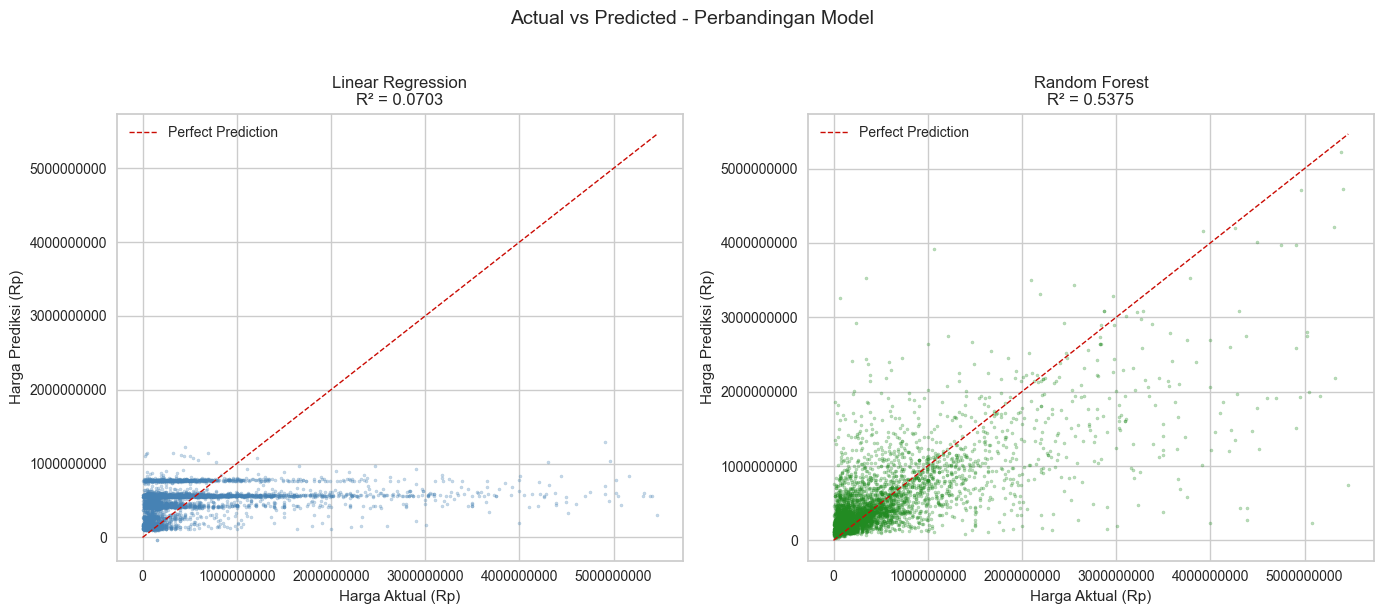

In [16]:
# 5.2 Visualisasi: Actual vs Predicted (kedua model)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sampling 5000 titik untuk visualisasi (lebih ringan)
idx = np.random.choice(len(y_test), size=min(5000, len(y_test)), replace=False)

# Linear Regression
axes[0].scatter(y_test.values[idx], y_pred_lr[idx], alpha=0.3, s=5, color='steelblue')
max_val = max(y_test.values[idx].max(), y_pred_lr[idx].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect Prediction')
axes[0].set_xlabel('Harga Aktual (Rp)')
axes[0].set_ylabel('Harga Prediksi (Rp)')
axes[0].set_title(f'Linear Regression\nR² = {lr_r2:.4f}', fontsize=12)
axes[0].legend()
axes[0].ticklabel_format(style='plain', axis='both')

# Random Forest
axes[1].scatter(y_test.values[idx], y_pred_rf[idx], alpha=0.3, s=5, color='forestgreen')
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect Prediction')
axes[1].set_xlabel('Harga Aktual (Rp)')
axes[1].set_ylabel('Harga Prediksi (Rp)')
axes[1].set_title(f'Random Forest\nR² = {rf_r2:.4f}', fontsize=12)
axes[1].legend()
axes[1].ticklabel_format(style='plain', axis='both')

plt.suptitle('Actual vs Predicted - Perbandingan Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

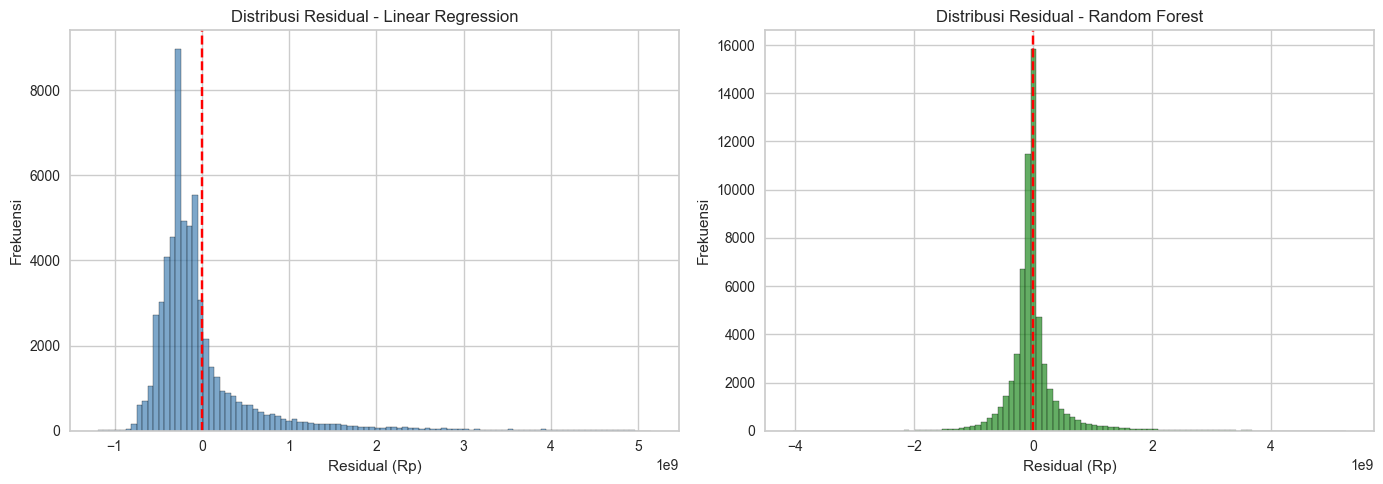

In [17]:
# 5.3 Distribusi Residual (Error) kedua model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residual_lr = y_test - y_pred_lr
residual_rf = y_test - y_pred_rf

axes[0].hist(residual_lr, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_title('Distribusi Residual - Linear Regression', fontsize=12)
axes[0].set_xlabel('Residual (Rp)')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(residual_rf, bins=100, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title('Distribusi Residual - Random Forest', fontsize=12)
axes[1].set_xlabel('Residual (Rp)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

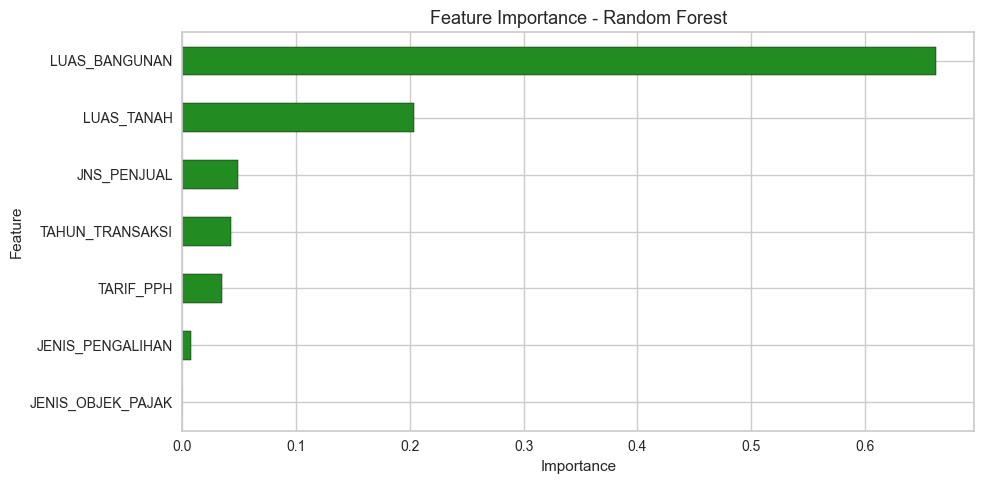


Feature Importance (descending):
  LUAS_BANGUNAN            : 0.6628 (66.3%)
  LUAS_TANAH               : 0.2034 (20.3%)
  JNS_PENJUAL              : 0.0489 (4.9%)
  TAHUN_TRANSAKSI          : 0.0424 (4.2%)
  TARIF_PPH                : 0.0352 (3.5%)
  JENIS_PENGALIHAN         : 0.0072 (0.7%)
  JENIS_OBJEK_PAJAK        : 0.0000 (0.0%)


In [18]:
# 5.4 Feature Importance (Random Forest)
feature_names = features_cat + features_num
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='barh', color='forestgreen', edgecolor='black')
plt.title('Feature Importance - Random Forest', fontsize=13)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nFeature Importance (descending):")
for feat, imp in feat_imp.sort_values(ascending=False).items():
    print(f"  {feat:25s}: {imp:.4f} ({imp*100:.1f}%)")

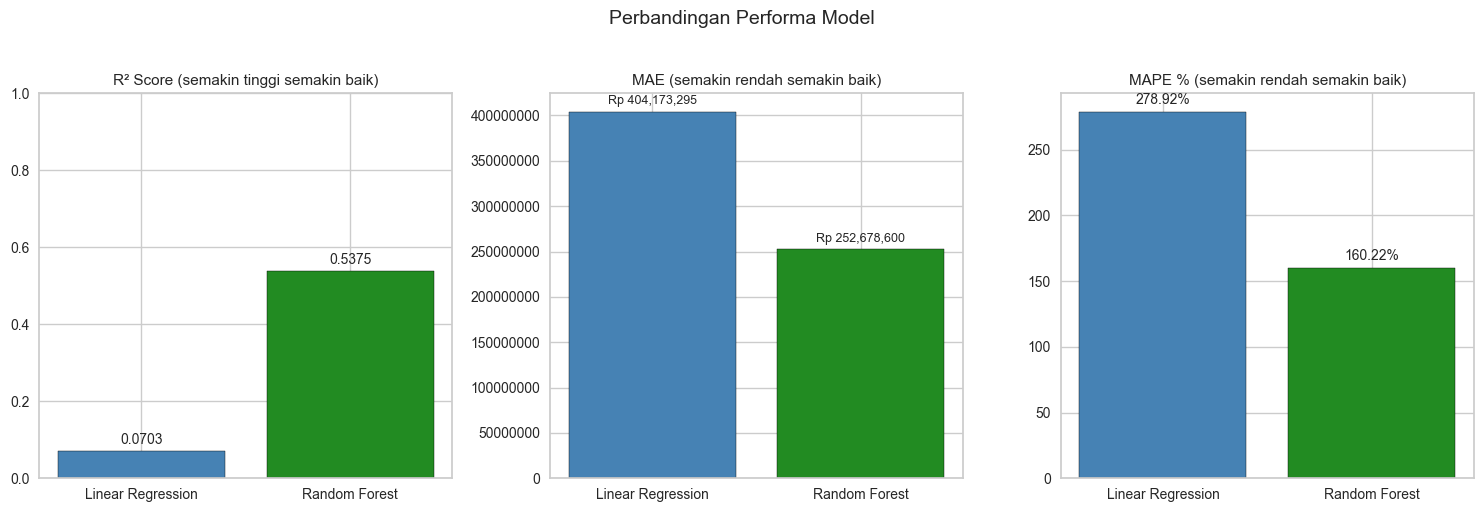

In [19]:
# 5.5 Perbandingan Metrik dalam Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R² Score
models = ['Linear Regression', 'Random Forest']
r2_scores = [lr_r2, rf_r2]
bars1 = axes[0].bar(models, r2_scores, color=['steelblue', 'forestgreen'], edgecolor='black')
axes[0].set_title('R² Score (semakin tinggi semakin baik)', fontsize=11)
axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.4f}', ha='center', fontsize=10)

# MAE
mae_scores = [lr_mae, rf_mae]
bars2 = axes[1].bar(models, mae_scores, color=['steelblue', 'forestgreen'], edgecolor='black')
axes[1].set_title('MAE (semakin rendah semakin baik)', fontsize=11)
axes[1].ticklabel_format(style='plain', axis='y')
for bar, val in zip(bars2, mae_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(mae_scores)*0.02, 
                f'Rp {val:,.0f}', ha='center', fontsize=9)

# MAPE
mape_scores = [lr_mape, rf_mape]
bars3 = axes[2].bar(models, mape_scores, color=['steelblue', 'forestgreen'], edgecolor='black')
axes[2].set_title('MAPE % (semakin rendah semakin baik)', fontsize=11)
for bar, val in zip(bars3, mape_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(mape_scores)*0.02, 
                f'{val:.2f}%', ha='center', fontsize=10)

plt.suptitle('Perbandingan Performa Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## CRISP-DM Phase 6: Deployment & Kesimpulan

### Kesimpulan

| Aspek | Linear Regression | Random Forest |
|---|---|---|
| **Kecepatan Training** | Sangat cepat | Lebih lambat (beberapa menit) |
| **Interpretabilitas** | Tinggi (koefisien jelas) | Sedang (feature importance) |
| **Kemampuan Prediksi** | Baseline | Lebih baik (non-linear) |
| **Cocok untuk** | Quick analysis, baseline | Produksi, deteksi anomali |

### Rekomendasi Penerapan di DJP
1. **Model Random Forest** direkomendasikan untuk deployment karena performa prediksi yang lebih baik
2. **Use Case Utama**: Deteksi transaksi PHTB dengan harga di bawah kewajaran — jika selisih antara harga aktual dan prediksi model terlalu besar (misal residual negatif > 2σ), transaksi dapat di-flag untuk penelitian lebih lanjut
3. **Feature `LUAS_TANAH` dan `LUAS_BANGUNAN`** adalah prediktor utama harga, sesuai dengan intuisi bisnis
4. **Limitasi**: Model ini dilatih dengan data nasional — untuk akurasi lebih tinggi, pertimbangkan menambahkan fitur lokasi (kode KPP/kabupaten) sebagai feature tambahan

### Langkah Selanjutnya (Deployment)
- Simpan model menggunakan `joblib` atau `pickle` untuk serving
- Integrasi dengan MLflow untuk experiment tracking dan model registry
- Buat API endpoint (Flask/FastAPI) untuk real-time prediction
- Monitoring model performance secara berkala (model drift detection)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.5s finished


Statistik Residual (Harga Aktual - Harga Prediksi):
  Mean     : Rp        -786,036
  Std      : Rp     467,847,993
  Threshold: Rp    -936,482,021

Jumlah transaksi anomali (harga < prediksi - 2σ): 971 dari 60,000
Persentase anomali: 1.62%


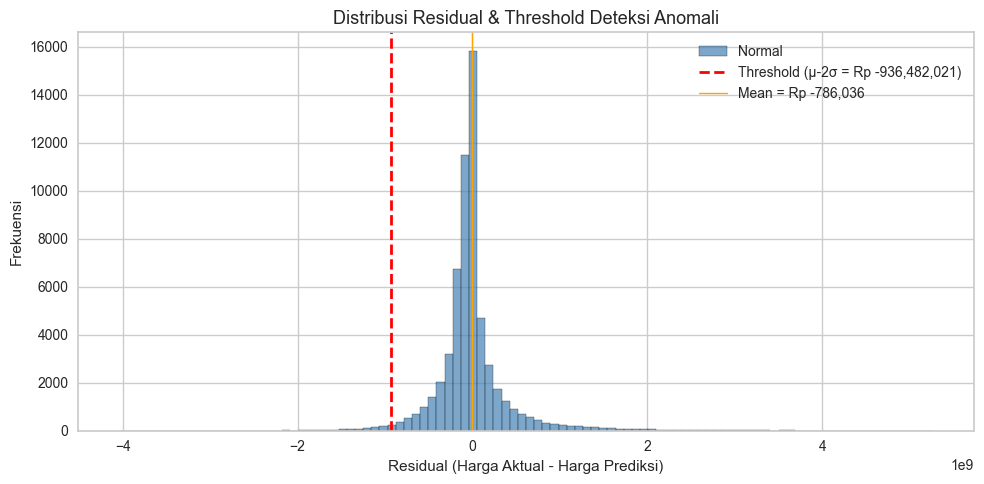

In [20]:
# 6.1 Contoh Deteksi Anomali Harga menggunakan Model Terbaik
# Gunakan model Random Forest untuk mendeteksi transaksi dengan harga di bawah kewajaran

y_pred_all = rf_model.predict(X_test_scaled)
residual = y_test - y_pred_all

# Hitung threshold: mean - 2*std (transaksi sangat undervalued)
mean_res = residual.mean()
std_res = residual.std()
threshold = mean_res - 2 * std_res

# Flag transaksi anomali (harga aktual jauh di bawah prediksi)
anomali_mask = residual < threshold
n_anomali = anomali_mask.sum()

print(f"Statistik Residual (Harga Aktual - Harga Prediksi):")
print(f"  Mean     : Rp {mean_res:>15,.0f}")
print(f"  Std      : Rp {std_res:>15,.0f}")
print(f"  Threshold: Rp {threshold:>15,.0f}")
print(f"\nJumlah transaksi anomali (harga < prediksi - 2σ): {n_anomali:,} dari {len(y_test):,}")
print(f"Persentase anomali: {n_anomali/len(y_test)*100:.2f}%")

# Visualisasi
plt.figure(figsize=(10, 5))
plt.hist(residual, bins=100, color='steelblue', edgecolor='black', alpha=0.7, label='Normal')
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold (μ-2σ = Rp {threshold:,.0f})')
plt.axvline(x=mean_res, color='orange', linestyle='-', linewidth=1, label=f'Mean = Rp {mean_res:,.0f}')
plt.title('Distribusi Residual & Threshold Deteksi Anomali', fontsize=13)
plt.xlabel('Residual (Harga Aktual - Harga Prediksi)')
plt.ylabel('Frekuensi')
plt.legend()
plt.tight_layout()
plt.show()